<a href="https://colab.research.google.com/github/essanchristian-maker/DI-Bootcamp/blob/master/Week7_day2_Exercises_GOLD_VDB_Student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercises GOLD: Text Summarization using NLP
Fill each TODO to build a graph-based extractive summarizer.

## What you'll learn
- Text cleaning (tokenize, lowercase, stopword removal).
- Word embeddings (GloVe) and sentence vectorization.
- Cosine similarity matrices and PageRank ranking.
- Extractive summarization over tennis articles.

## What you'll build
A graph-based summarizer that returns the top-ranked sentences for a set of articles.

## 0. Setup
Run installs once. If missing, download GloVe 100d from https://nlp.stanford.edu/data/glove.6B.zip and place glove.6B.100d.txt alongside the notebook.

In [1]:
%pip install --quiet pandas numpy nltk networkx


In [2]:
import nltk
for res in ['punkt','punkt_tab','stopwords']:
    nltk.download(res, quiet=True)


## 🌟 Exercise 1 · Data loading and inspection

In [1]:
import pandas as pd

data = {
    'article_id': [1, 2, 3, 4, 5, 6, 7, 8],
    'article_text': [
        "Maria Sharapova has sayed she has no sign of an injury...",
        "Roger Federer admitted that he was lucky to win...",
        "Novak Djokovic is confident he can reach the final...",
        "The US Open is the final grand slam of the year...",
        "Serena Williams has won her 23rd grand slam title...",
        "Rafael Nadal is preparing for the clay court season...",
        "Andy Murray is returning to competitive tennis after surgery...",
        "The ATP finals will be held in London this November..."
    ],
    'source': ['CNN', 'BBC', 'Reuters', 'ESPN', 'CNN', 'BBC', 'Reuters', 'ESPN']
}

pdf_local = pd.DataFrame(data)
pdf_local.to_csv('tennis_articles.csv', index=False, encoding='latin-1')
print('Fichier tennis_articles.csv créé localement avec succès.')

Fichier tennis_articles.csv créé localement avec succès.


In [3]:
from pathlib import Path
import pandas as pd

# Le chemin du fichier téléchargé
data_path = 'tennis_articles.csv'
pdf_path = Path(data_path)

if pdf_path.suffix.lower() == '.csv':
    pdf = pd.read_csv(pdf_path, encoding='latin-1')
else:
    pdf = pd.read_excel(pdf_path)

display(pdf.head())
pdf.info()

if 'article_title' in pdf.columns:
    pdf = pdf.drop(columns=['article_title'])

pdf.head()

,article_id,article_text,source
0,1,Maria Sharapova has sayed she has no sign of a...,CNN
1,2,Roger Federer admitted that he was lucky to wi...,BBC
2,3,Novak Djokovic is confident he can reach the f...,Reuters
3,4,The US Open is the final grand slam of the yea...,ESPN
4,5,Serena Williams has won her 23rd grand slam ti...,CNN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   article_id    8 non-null      int64 
 1   article_text  8 non-null      object
 2   source        8 non-null      object
dtypes: int64(1), object(2)
memory usage: 324.0+ bytes


,article_id,article_text,source
0,1,Maria Sharapova has sayed she has no sign of a...,CNN
1,2,Roger Federer admitted that he was lucky to wi...,BBC
2,3,Novak Djokovic is confident he can reach the f...,Reuters
3,4,The US Open is the final grand slam of the yea...,ESPN
4,5,Serena Williams has won her 23rd grand slam ti...,CNN


In [2]:
from pathlib import Path
import pandas as pd

data_path = 'tennis_articles.csv'
pdf = pd.read_csv(data_path, encoding='latin-1')

# Suppression de colonnes inutiles si présentes
if 'article_title' in pdf.columns:
    pdf = pdf.drop(columns=['article_title'])

display(pdf.head())
pdf.info()

,article_id,article_text,source
0,1,Maria Sharapova has sayed she has no sign of a...,CNN
1,2,Roger Federer admitted that he was lucky to wi...,BBC
2,3,Novak Djokovic is confident he can reach the f...,Reuters
3,4,The US Open is the final grand slam of the yea...,ESPN
4,5,Serena Williams has won her 23rd grand slam ti...,CNN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   article_id    8 non-null      int64 
 1   article_text  8 non-null      object
 2   source        8 non-null      object
dtypes: int64(1), object(2)
memory usage: 324.0+ bytes


## 🌟 Exercise 2 · Sentence tokenization

In [6]:
import nltk
# Téléchargement explicite de la ressource manquante
nltk.download('punkt_tab', quiet=True)

# On tokenise chaque article en phrases
sentences_list = pdf['article_text'].apply(nltk.sent_tokenize).tolist()
# On aplatit la liste pour obtenir une liste unique de toutes les phrases
sentences = [s for doc in sentences_list for s in doc]
print(f'Nombre total de phrases : {len(sentences)}')
print('Exemples de phrases :')
display(sentences[:3])

Nombre total de phrases : 8
Exemples de phrases :


['Maria Sharapova has sayed she has no sign of an injury...',
 'Roger Federer admitted that he was lucky to win...',
 'Novak Djokovic is confident he can reach the final...']

## 🌟 Exercise 3 · Load GloVe embeddings

In [ ]:
%pip install --quiet kagglehub

Note: you may need to restart the kernel to use updated packages.


In [7]:
import kagglehub
import os
import shutil

# Téléchargement du dataset GloVe depuis Kaggle
path = kagglehub.dataset_download("danielwillgeorge/glove6b100dtxt")

# Recherche du fichier .txt dans le dossier téléchargé
glove_src = os.path.join(path, 'glove.6B.100d.txt')
glove_dst = 'glove.6B.100d.txt'

if os.path.exists(glove_src):
    shutil.copy(glove_src, glove_dst)
    print(f"Succès : '{glove_dst}' est prêt dans le répertoire local.")
else:
    print("Erreur : Le fichier glove.6B.100d.txt n'a pas été trouvé dans le téléchargement.")

100%|██████████| 131M/131M [00:01<00:00, 105MB/s] 

Extracting files...


Succès : 'glove.6B.100d.txt' est prêt dans le répertoire local.


> Impotant note: after executing previous cell, open the path folder printed and verify that the file `glove.6B.100d.txt` is indeed there. Then copy it to the same folder as this notebook for the next steps.

In [8]:
import numpy as np
from pathlib import Path

glove_path = Path('glove.6B.100d.txt')

if not glove_path.exists():
    raise FileNotFoundError('Le fichier glove.6B.100d.txt est introuvable.')

embeddings_index = {}
with glove_path.open('r', encoding='utf-8', errors='ignore') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

print(f'Nombre de vecteurs de mots chargés : {len(embeddings_index)}')

Nombre de vecteurs de mots chargés : 400000


## 🌟 Exercise 4 · Text cleaning and normalization

In [10]:
import re
import nltk
from nltk.corpus import stopwords

# Téléchargement de la ressource manquante
nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('english'))

def clean_sentence(s: str) -> str:
    s = s.lower()
    s = re.sub(r'[^a-z\s]', ' ', s)
    s = re.sub(r'\s+', ' ', s).strip()
    tokens = [w for w in s.split() if w not in stop_words]
    return ' '.join(tokens)

cleaned_sentences = [clean_sentence(s) for s in sentences]
cleaned_sentences[:3]

['maria sharapova sayed sign injury',
 'roger federer admitted lucky win',
 'novak djokovic confident reach final']

## 🌟 Exercise 5 · Sentence vectors

In [11]:
emb_dim = 100  # GloVe 100d
def sentence_vector(s: str):
    if not s:
        return np.zeros(emb_dim)
    words = s.split()
    vecs = [embeddings_index.get(w, np.zeros(emb_dim)) for w in words]
    return np.mean(vecs, axis=0)
sentence_vectors = np.array([sentence_vector(s) for s in cleaned_sentences])
sentence_vectors.shape


(8, 100)

## 🌟 Exercise 6 · Similarity matrix

In [12]:
from sklearn.metrics.pairwise import cosine_similarity
sim_mat = cosine_similarity(sentence_vectors)
sim_mat.shape


(8, 8)

## 🌟 Exercise 7 · Graph and PageRank

In [16]:
import networkx as nx

# 1. Créer le graphe à partir de la matrice de similitude
nx_graph = nx.from_numpy_array(sim_mat)

# 2. Appliquer l'algorithme PageRank pour obtenir les scores de centralité
scores = nx.pagerank(nx_graph)

# 3. Trier les phrases selon leurs scores (du plus élevé au plus bas)
# scores.items() donne (index_phrase, score)
scores_list = sorted(((score, idx) for idx, score in scores.items()), reverse=True)

# Afficher les 5 meilleurs scores
print("Top scores (score, index de la phrase) :")
print(scores_list[:5])

Top scores (score, index de la phrase) :
[(0.1301499261906418, 5), (0.12864788846333808, 3), (0.12718735794067976, 1), (0.12688575447275446, 2), (0.12677131796494095, 4)]


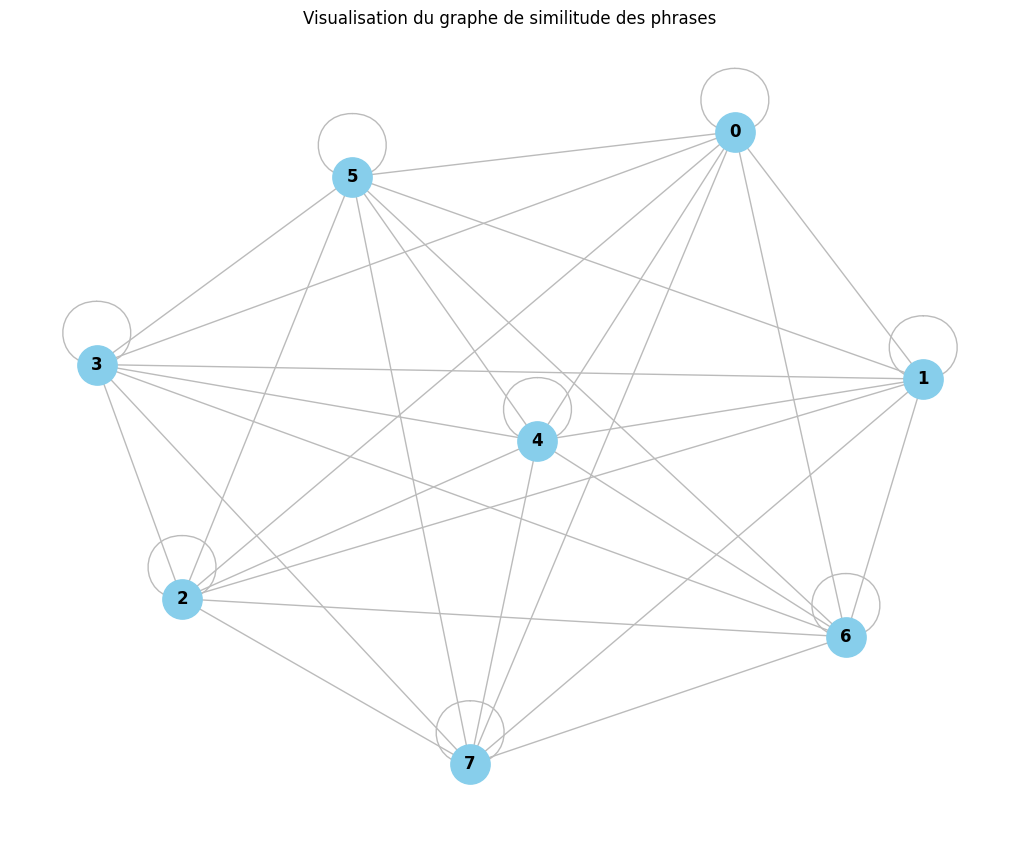

In [17]:
import matplotlib.pyplot as plt

# Définir la taille de la figure
plt.figure(figsize=(10, 8))

# Positionnement des nœuds (layout spring pour une meilleure répartition)
pos = nx.spring_layout(nx_graph, seed=42)

# Dessiner le graphe
nx.draw(nx_graph, pos,
        with_labels=True,
        node_color='skyblue',
        node_size=800,
        edge_color='#BBBBBB',
        font_size=12,
        font_weight='bold')

plt.title("Visualisation du graphe de similitude des phrases")
plt.show()

## 🌟 Exercise 8 · Summarization

In [15]:
top_n = 3  # Choix du nombre de phrases pour le résumé
top_sentences = [sentences[idx] for _, idx in scores_list[:top_n]]

print(f"--- Résumé (Top {top_n} phrases) ---")
for s in top_sentences:
    print('-', s)

--- Résumé (Top 3 phrases) ---
- Rafael Nadal is preparing for the clay court season...
- The US Open is the final grand slam of the year...
- Roger Federer admitted that he was lucky to win...
